In [2]:
import csv
import json
from datetime import datetime

ARQUIVO_CSV = "transacoes.csv"
ARQUIVO_JSON = "relatorio.json"
LIMITE_SUSPEITO = 10000.00

In [3]:
def ler_transacoes(caminho):
    transacoes = []
    try:
        with open(caminho, newline='', encoding='utf-8') as arquivo:
            leitor = csv.DictReader(arquivo)
            for linha in leitor:
                transacoes.append(linha)
    except FileNotFoundError:
        print(f"ERRO: Arquivo '{caminho}' não encontrado.")
    return transacoes


dados_brutos = ler_transacoes(ARQUIVO_CSV)
print(f"Total de linhas lidas: {len(dados_brutos)}")

Total de linhas lidas: 25


In [4]:
def validar_transacao(linha):
    try:
        if not linha.get('id') or not linha['id'].strip().isdigit():
            return None

        if not linha.get('cliente_id') or not linha['cliente_id'].strip():
            return None

        try:
            data = datetime.strptime(linha['data'].strip(), "%Y-%m-%d")
        except (ValueError, KeyError):
            return None

        tipo = linha.get('tipo', '').strip().lower()
        if tipo not in ('credito', 'debito'):
            return None

        try:
            valor = float(linha['valor'].strip())
            if valor <= 0:
                return None
        except (ValueError, KeyError):
            return None

        return {
            'id': int(linha['id'].strip()),
            'data': data,
            'mes': data.strftime("%Y-%m"),
            'cliente_id': linha['cliente_id'].strip(),
            'tipo': tipo,
            'valor': valor,
            'descricao': linha.get('descricao', '').strip(),
            'categoria': linha.get('categoria', '').strip(),
        }
    except Exception:
        return None

exemplo = validar_transacao({
    'id': '1', 'data': '2026-01-05', 'cliente_id': 'CLI001',
    'tipo': 'credito', 'valor': '3500.00',
    'descricao': 'Salário', 'categoria': 'salario'
})
print("Exemplo válido:", exemplo['id'], exemplo['valor'])

Exemplo válido: 1 3500.0


In [5]:
def gerar_relatorio(transacoes_validas):
    resumo = {}
    suspeitas = []

    for t in transacoes_validas:
        mes = t['mes']

        if mes not in resumo:
            resumo[mes] = {
                'quantidade': 0,
                'total_credito': 0.0,
                'total_debito': 0.0,
                'valores': [],
            }

        resumo[mes]['quantidade'] += 1
        resumo[mes]['valores'].append(t['valor'])

        if t['tipo'] == 'credito':
            resumo[mes]['total_credito'] += t['valor']
        else:
            resumo[mes]['total_debito'] += t['valor']

        if t['valor'] > LIMITE_SUSPEITO:
            suspeitas.append(t)

    for mes, dados in resumo.items():
        dados['saldo'] = dados['total_credito'] - dados['total_debito']
        dados['media'] = sum(dados['valores']) / len(dados['valores'])
        dados['maior_valor'] = max(dados['valores'])
        dados['menor_valor'] = min(dados['valores'])

    return dict(sorted(resumo.items())), suspeitas

print("Função gerar_relatorio definida.")

Função gerar_relatorio definida.


In [6]:
def formatar_brl(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

def exibir_relatorio(resumo, suspeitas, validas, invalidas, datas):
    print("=" * 40)
    print("       RELATÓRIO CLEARBANK")
    print("=" * 40)
    print(f"Período analisado: {datas[0]} → {datas[1]}")
    print(f"Total transações válidas:   {validas}")
    print(f"Total transações inválidas: {invalidas}")
    print()

    print("===== RELATÓRIO MENSAL =====")
    for mes, dados in resumo.items():
        print(f"\nMês: {mes}")
        print(f"  Transações: {dados['quantidade']}")
        print(f"  Total crédito: {formatar_brl(dados['total_credito'])}")
        print(f"  Total débito:  {formatar_brl(dados['total_debito'])}")
        print(f"  Saldo:         {formatar_brl(dados['saldo'])}")
        print(f"  Média:         {formatar_brl(dados['media'])}")
        print(f"  Maior valor:   {formatar_brl(dados['maior_valor'])}")
        print(f"  Menor valor:   {formatar_brl(dados['menor_valor'])}")

    print()
    print("===== TRANSAÇÕES SUSPEITAS =====")
    if suspeitas:
        for t in suspeitas:
            print(f"ID: {t['id']} | Cliente: {t['cliente_id']} | Data: {t['data'].strftime('%Y-%m-%d')} | Valor: {formatar_brl(t['valor'])}")
    else:
        print("Nenhuma transação suspeita encontrada.")

print("Funções de exibição definidas.")

Funções de exibição definidas.


In [7]:
def salvar_json(resumo, suspeitas, validas, invalidas):
    resumo_serial = {}
    for mes, dados in resumo.items():
        resumo_serial[mes] = {
            'quantidade': dados['quantidade'],
            'total_credito': round(dados['total_credito'], 2),
            'total_debito': round(dados['total_debito'], 2),
            'saldo': round(dados['saldo'], 2),
            'media': round(dados['media'], 2),
            'maior_valor': dados['maior_valor'],
            'menor_valor': dados['menor_valor'],
        }

    saida = {
        'gerado_em': datetime.today().strftime('%Y-%m-%d'),
        'total_transacoes_validas': validas,
        'total_transacoes_invalidas': invalidas,
        'resumo_mensal': resumo_serial,
        'transacoes_suspeitas': [
            {
                'id': t['id'],
                'cliente_id': t['cliente_id'],
                'data': t['data'].strftime('%Y-%m-%d'),
                'valor': t['valor'],
            }
            for t in suspeitas
        ]
    }

    try:
        with open(ARQUIVO_JSON, 'w', encoding='utf-8') as f:
            json.dump(saida, f, ensure_ascii=False, indent=2)
        print(f"Arquivo '{ARQUIVO_JSON}' salvo com sucesso.")
    except Exception as e:
        print(f"Erro ao salvar JSON: {e}")

print("Função salvar_json definida.")

Função salvar_json definida.


In [8]:
# 1. Lê o CSV
dados_brutos = ler_transacoes(ARQUIVO_CSV)

# 2. Valida cada linha
transacoes_validas = []
for linha in dados_brutos:
    resultado = validar_transacao(linha)
    if resultado:
        transacoes_validas.append(resultado)

total_validas = len(transacoes_validas)
total_invalidas = len(dados_brutos) - total_validas

print(f"Total de linhas lidas: {len(dados_brutos)}")
print(f"Linhas válidas:   {total_validas}")
print(f"Linhas inválidas: {total_invalidas}")
print()

# 3. Calcula período
datas_ordenadas = sorted([t['data'] for t in transacoes_validas])
periodo = (
    datas_ordenadas[0].strftime('%Y-%m-%d'),
    datas_ordenadas[-1].strftime('%Y-%m-%d')
)
dias = (datas_ordenadas[-1] - datas_ordenadas[0]).days
print(f"Período: {periodo[0]} → {periodo[1]} ({dias} dias)\n")

# 4. Gera relatório
resumo, suspeitas = gerar_relatorio(transacoes_validas)

# 5. Exibe no terminal
exibir_relatorio(resumo, suspeitas, total_validas, total_invalidas, periodo)

# 6. Salva JSON
salvar_json(resumo, suspeitas, total_validas, total_invalidas)

Total de linhas lidas: 25
Linhas válidas:   20
Linhas inválidas: 5

Período: 2026-01-05 → 2026-04-30 (115 dias)

       RELATÓRIO CLEARBANK
Período analisado: 2026-01-05 → 2026-04-30
Total transações válidas:   20
Total transações inválidas: 5

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 5
  Total crédito: R$ 17.300,00
  Total débito:  R$ 430,50
  Saldo:         R$ 16.869,50
  Média:         R$ 3.546,10
  Maior valor:   R$ 12.000,00
  Menor valor:   R$ 180,50

Mês: 2026-02
  Transações: 5
  Total crédito: R$ 18.500,00
  Total débito:  R$ 869,90
  Saldo:         R$ 17.630,10
  Média:         R$ 3.873,98
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 99,90

Mês: 2026-03
  Transações: 5
  Total crédito: R$ 5.700,00
  Total débito:  R$ 829,90
  Saldo:         R$ 4.870,10
  Média:         R$ 1.305,98
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 99,90

Mês: 2026-04
  Transações: 5
  Total crédito: R$ 5.500,00
  Total débito:  R$ 1.020,00
  Saldo:         R$ 4.480,00
  Méd

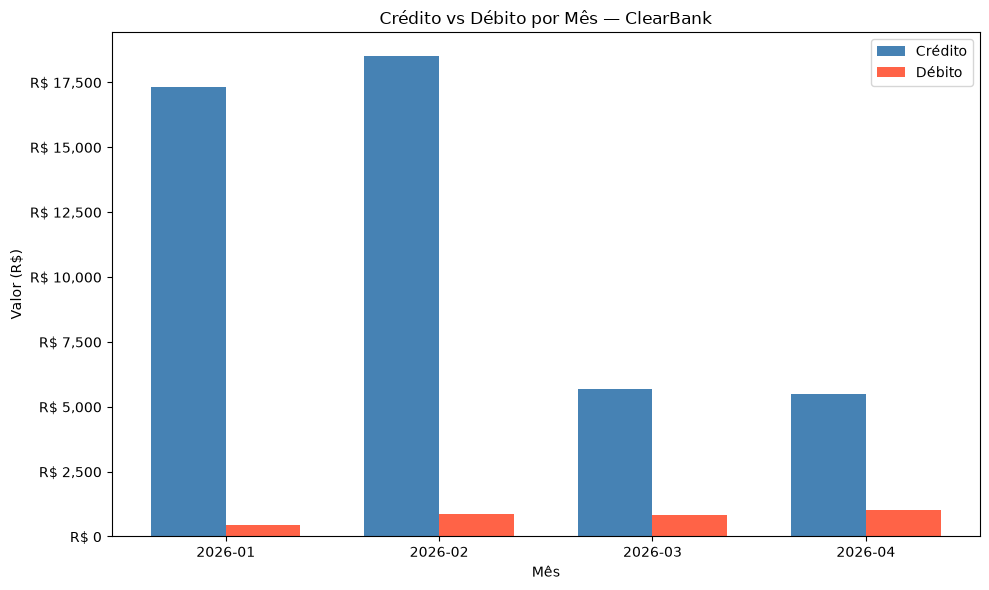

Gráfico salvo como grafico.png


In [9]:
import matplotlib.pyplot as plt

meses = list(resumo.keys())
creditos = [resumo[m]['total_credito'] for m in meses]
debitos  = [resumo[m]['total_debito']  for m in meses]

x = range(len(meses))
largura = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
barras_c = ax.bar([i - largura/2 for i in x], creditos, largura, label='Crédito', color='steelblue')
barras_d = ax.bar([i + largura/2 for i in x], debitos,  largura, label='Débito',  color='tomato')

ax.set_title('Crédito vs Débito por Mês — ClearBank')
ax.set_xlabel('Mês')
ax.set_ylabel('Valor (R$)')
ax.set_xticks(list(x))
ax.set_xticklabels(meses)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'R$ {v:,.0f}'))

plt.tight_layout()
plt.savefig('grafico.png')
plt.show()
print("Gráfico salvo como grafico.png")